In [1]:
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
import numpy as np

In [2]:
!pip install  sentence_transformers

In [3]:
from sentence_transformers import SentenceTransformer
model = SentenceTransformer('all-MiniLM-L6-v2')

documents = [
"Neural networks are machine learning models inspired by the human brain.",
"Backpropagation is used to train neural networks.",
"Transformers use attention mechanisms.",
"Climate change refers to long-term temperature shifts.",
"Football is a popular global sport.",
"The Moon is Earth's natural satellite."
]

embeddings = model.encode(documents)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

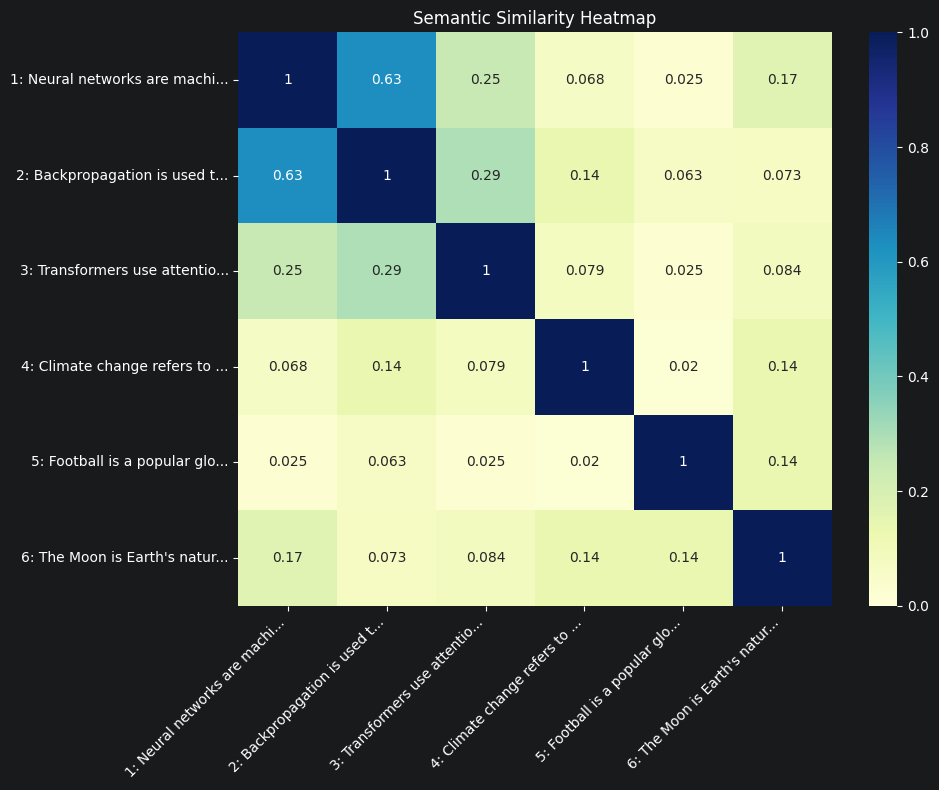

In [4]:
import seaborn as sns
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

# 1. Calculate the similarity matrix
# embeddings.shape is (6, 384) -> similarity_matrix.shape will be (6, 6)
sim_matrix = cosine_similarity(embeddings)

# 2. Shorten document labels for the plot
labels = [f"{i+1}: {doc[:25]}..." for i, doc in enumerate(documents)]

# 3. Create the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    sim_matrix, 
    annot=True,          # Show the actual scores
    xticklabels=labels, 
    yticklabels=labels, 
    cmap="YlGnBu",       # Yellow-Green-Blue color palette
    vmin=0, vmax=1       # Force scale from 0 to 1
)

plt.title("Semantic Similarity Heatmap")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

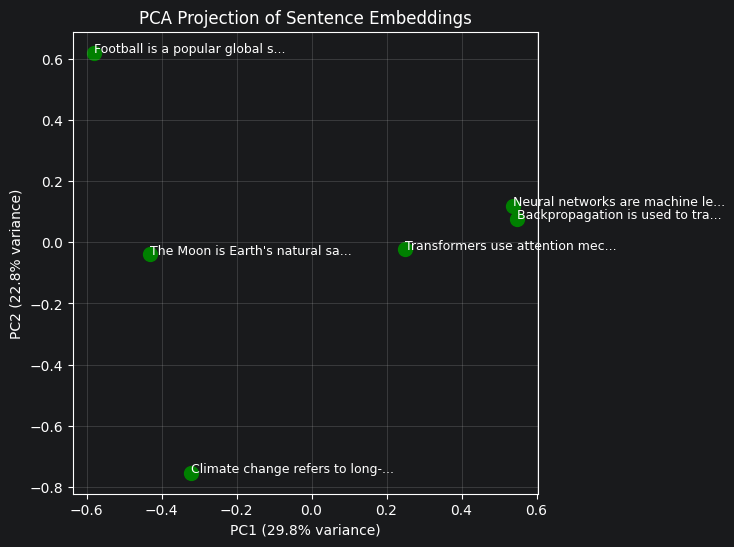

In [5]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1. Run PCA
# We reduce to 2 components for a 2D plot
pca = PCA(n_components=2)
pca_results = pca.fit_transform(embeddings)

# 2. Plotting
plt.figure(figsize=(6, 6))
plt.scatter(pca_results[:, 0], pca_results[:, 1], c='green', s=100)

for i, doc in enumerate(documents):
    plt.annotate(doc[:30] + "...", (pca_results[i, 0], pca_results[i, 1]), fontsize=9)

plt.title("PCA Projection of Sentence Embeddings")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.grid(True, alpha=0.3)
plt.show()

In [6]:
Q = "What is attention in transformers?"
Q_emb = model.encode([Q])
scores = cosine_similarity(Q_emb, embeddings)[0]
top_idx = scores.argsort()[-3:][::-1]
results = [documents[i] for i in top_idx]
for r in results:
    print("-", r)


- Transformers use attention mechanisms.
- Backpropagation is used to train neural networks.
- Neural networks are machine learning models inspired by the human brain.
